# Validacio dels datasets de modelatge

Aquest notebook no te com a objectiu fer una analisi descriptiva de la gentrificació. Prioritzarem validar si els datasets finals estan preparats per a la fase de clustering.

Objectius:
- comprovar estructures entre datasets
- detectar valors nuls, infinits i possibles errors de calcul
- revisar distribucions i outliers
- documentar decisions abans del clustering

# Llibreries i configuracio

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme()

BASE_DIR = Path('..')
DATA_DIR = BASE_DIR/'data'
RESULTS_DIR = BASE_DIR/'results'/'figs'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Carrega de dades

In [2]:
dim_barris = pd.read_csv(DATA_DIR/'dimensions'/'BarcelonaCiutat_Barris.csv')
df_2015 = pd.read_csv(DATA_DIR/'modelling'/'df_2015.csv')
df_2023 = pd.read_csv(DATA_DIR/'modelling'/'df_2023.csv')
df_deltes = pd.read_csv(DATA_DIR/'modelling'/'df_deltes.csv')

print('dim_barris:', dim_barris.shape)
print('df_2015:', df_2015.shape)
print('df_2023:', df_2023.shape)
print('df_deltes:', df_deltes.shape)

dim_barris: (73, 6)
df_2015: (73, 14)
df_2023: (73, 14)
df_deltes: (73, 14)


# Funcions auxiliars

In [3]:
def resum_estructura(df, nom_dataset):
    """
    Funció per estudiar l'estructura de les dades d' un dataset i detectar valors nuls, infinits, i valors únics.
    """
    resum = pd.DataFrame({
        'tipus': df.dtypes.astype(str),
        'nuls': df.isna().sum(),
        'infinits': np.isinf(df.select_dtypes(include=[np.number])).sum().reindex(df.columns, fill_value=0),
    })
    resum.index.name = f'columna ({nom_dataset})'
    return resum


def resum_numerics(df, exclou=('codi_barri',)):
    """
    Funció per estudiar les distribucions dels atributs d' un dataset
    """
    cols = [c for c in df.columns if c not in exclou]
    resum = df[cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
    resum['asimetria'] = df[cols].skew(numeric_only=True)
    return resum.sort_values('asimetria', key=lambda s: s.abs(), ascending=False)


def files_problematiques(df, dim, dataset_name):
    """
    Funció per trobar records amb problemes com infinits o NaNs
    """
    numeric_cols = [c for c in df.columns if c != 'codi_barri']
    problemes = []
    for col in numeric_cols:
        s = df[col]
        mask = s.isna() | np.isinf(s)
        if mask.any():
            tmp = df.loc[mask, ['codi_barri', col]].merge(
                dim[['codi_barri', 'nom_barri']],
                on='codi_barri',
                how='left'
            )
            tmp.insert(0, 'dataset', dataset_name)
            tmp.insert(1, 'variable', col)
            problemes.append(tmp.rename(columns={col: 'valor'}))
    if problemes:
        return pd.concat(problemes, ignore_index=True)
    return pd.DataFrame(columns=['dataset', 'variable', 'codi_barri', 'nom_barri', 'valor'])


def validacio_proporcions(df, dataset_name):
    """
    Comprova si la columna és superior a 1 o inferior a 0 en els casos que no ho pugui ser.
    """
    resultat = []
    for col in df.columns:
        if col.startswith('pct_'):
            fora_rang = ((df[col] < 0) | (df[col] > 1)).sum()
            resultat.append({'dataset': dataset_name, 'variable': col, 'fora_rang_0_1': int(fora_rang)})
    return pd.DataFrame(resultat)


def grafics_distribucio(df, titol, nom_fitxer):
    """
    Resumeix gràficament les distribucions de les variables
    """
    cols = [c for c in df.columns if c != 'codi_barri']
    ncols = 3
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, cols):
        sns.histplot(df[col], kde=True, ax=ax)
        ax.set_title(col)

    for ax in axes[len(cols):]:
        ax.axis('off')

    fig.suptitle(titol, fontsize=14)
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / nom_fitxer, dpi=150, bbox_inches='tight')
    plt.show()


def boxplots_validacio(df, titol, nom_fitxer):
    """
    Funció per resumir amb boxplots les distribucions de les variables
    """
    cols = [c for c in df.columns if c != 'codi_barri']
    ncols = 3
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, cols):
        sns.boxplot(x=df[col], ax=ax)
        ax.set_title(col)

    for ax in axes[len(cols):]:
        ax.axis('off')

    fig.suptitle(titol, fontsize=14)
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / nom_fitxer, dpi=150, bbox_inches='tight')
    plt.show()


def corr_plot(df, titol, nom_fitxer):
    """
    Funció per mostrar de manera gràfica la matriu de correlació.
    """
    cols = [c for c in df.columns if c!= 'codi_barri']
    
    cor_matrix = df[cols].corr()

    mask = np.triu(np.ones_like(cor_matrix, dtype=bool))

    plt.figure(figsize=(11, 9))
    sns.heatmap(cor_matrix, mask = mask, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            square=True, linewidths=.5)
    plt.ylabel("Atributs")
    plt.xlabel("Atributs")
    plt.title(titol)
    plt.savefig(RESULTS_DIR / nom_fitxer, dpi = 150, bbox_inches = 'tight')
    plt.show()


# 1. Validacio estructural

En aquest apartat comprovem que els tres datasets comparteixen l'estructura esperada per treballar amb barris de Barcelona.

In [4]:
expected_barri_count = dim_barris['codi_barri'].nunique()
print('Nombre de barris a la dimensio:', expected_barri_count)
print('Barris unics df_2015:', df_2015['codi_barri'].nunique())
print('Barris unics df_2023:', df_2023['codi_barri'].nunique())
print('Barris unics df_deltes:', df_deltes['codi_barri'].nunique())

print('Duplicats per codi_barri')
print('df_2015:', df_2015['codi_barri'].duplicated().sum())
print('df_2023:', df_2023['codi_barri'].duplicated().sum())
print('df_deltes:', df_deltes['codi_barri'].duplicated().sum())

Nombre de barris a la dimensio: 73
Barris unics df_2015: 73
Barris unics df_2023: 73
Barris unics df_deltes: 73
Duplicats per codi_barri
df_2015: 0
df_2023: 0
df_deltes: 0


**Observacions:**
- No falten barris
- No hi ha barris duplicasts

In [5]:
barri_sets = {
    'dimensio': set(dim_barris['codi_barri']),
    'df_2015': set(df_2015['codi_barri']),
    'df_2023': set(df_2023['codi_barri']),
    'df_deltes': set(df_deltes['codi_barri'])
}

for nom, values in barri_sets.items():
    if nom == 'dimensio':
        continue
    print(f'{nom}')
    print('Falten a la dimensio:', sorted(values - barri_sets['dimensio']))
    print('Falten al dataset:', sorted(barri_sets['dimensio'] - values))

df_2015
Falten a la dimensio: []
Falten al dataset: []
df_2023
Falten a la dimensio: []
Falten al dataset: []
df_deltes
Falten a la dimensio: []
Falten al dataset: []


**Observacions:**
- No falta cap barri al nostres datasets

In [6]:
resum_estructura(df_2015, 'df_2015')

,tipus,nuls,infinits
columna (df_2015),,,
codi_barri,int64,0,0
poblacio_total,int64,0,0
pct_pob_estrangera,float64,0,0
pct_pob_estrangera_occidental,float64,0,0
pct_joves,float64,0,0
pct_universitaris,float64,0,0
import_euros,float64,0,0
index_gini,float64,0,0
total_incidents_1000_hab,float64,0,0


**Observacions:**
- No s' observen valors nuls ni infinits per al conjunt de dades de 2015.

In [7]:
resum_estructura(df_2023, 'df_2023')

,tipus,nuls,infinits
columna (df_2023),,,
codi_barri,int64,0,0
poblacio_total,int64,0,0
pct_pob_estrangera,float64,0,0
pct_pob_estrangera_occidental,float64,0,0
pct_joves,float64,0,0
pct_universitaris,float64,0,0
import_euros,float64,0,0
index_gini,float64,0,0
total_incidents_1000_hab,float64,0,0


**Observacions:**
- No s' observen valors nuls ni infinits per al conjunt de dades de 2023.

In [8]:
resum_estructura(df_deltes, 'df_deltes')

,tipus,nuls,infinits
columna (df_deltes),,,
codi_barri,int64,0,0
delta_pct_pob_estrangera,float64,0,0
delta_pct_pob_estrangera_occidental,float64,0,0
delta_pct_joves,float64,0,0
delta_pct_universitaris,float64,0,0
delta_poblacio_total,float64,0,0
delta_import_euros,float64,0,0
delta_index_gini,float64,0,0
delta_total_incidents_1000_hab,float64,0,0


**Observacions:**

En una primera iteració, apareixien variables amb valors nuls (delta_locals_serveis_professionals_1000_hab i delta_locals_sanitaris_1000_hab per exemple). Després d'aplicar una neteja més exhaustiva i la creació de variables i deltes d' una manera més robusta, els nuls i infinits han desaparegut del dataset final.

# 2. Validacio de consistència

Aquesta seccio s'enfoca a identificar i analitzar els valors nuls i infinits.

In [9]:
problemes_2015 = files_problematiques(df_2015, dim_barris, 'df_2015')
problemes_2023 = files_problematiques(df_2023, dim_barris, 'df_2023')
problemes_deltes = files_problematiques(df_deltes, dim_barris, 'df_deltes')

problemes = pd.concat([problemes_2015, problemes_2023, problemes_deltes], ignore_index=True)
problemes

,dataset,variable,codi_barri,nom_barri,valor


**Observacions:**
- No apareixen més files problematiques després dels canvis

In [10]:
proporcions_2015 = validacio_proporcions(df_2015, 'df_2015')
proporcions_2023 = validacio_proporcions(df_2023, 'df_2023')

pd.concat([proporcions_2015, proporcions_2023], ignore_index=True)

,dataset,variable,fora_rang_0_1
0,df_2015,pct_pob_estrangera,0
1,df_2015,pct_pob_estrangera_occidental,0
2,df_2015,pct_joves,0
3,df_2015,pct_universitaris,0
4,df_2023,pct_pob_estrangera,0
5,df_2023,pct_pob_estrangera_occidental,0
6,df_2023,pct_joves,0
7,df_2023,pct_universitaris,0


**Observacions:**
- No existeixen dades fora dels rangs previstos

In [11]:
checks_addicionals = pd.DataFrame([
    {'dataset': 'df_2015', 'variable': 'index_gini', 'fora_rang_0_100': int(((df_2015['index_gini'] < 0) | (df_2015['index_gini'] > 100)).sum())},
    {'dataset': 'df_2023', 'variable': 'index_gini', 'fora_rang_0_100': int(((df_2023['index_gini'] < 0) | (df_2023['index_gini'] > 100)).sum())},
    {'dataset': 'df_2015', 'variable': 'preu_mitja_m2', 'negatius': int((df_2015['preu_mitja_m2'] < 0).sum())},
    {'dataset': 'df_2023', 'variable': 'preu_mitja_m2', 'negatius': int((df_2023['preu_mitja_m2'] < 0).sum())},
    {'dataset': 'df_2015', 'variable': 'import_euros', 'negatius': int((df_2015['import_euros'] < 0).sum())},
    {'dataset': 'df_2023', 'variable': 'import_euros', 'negatius': int((df_2023['import_euros'] < 0).sum())}
])
checks_addicionals

,dataset,variable,fora_rang_0_100,negatius
0,df_2015,index_gini,0.0,NaN
1,df_2023,index_gini,0.0,NaN
2,df_2015,preu_mitja_m2,NaN,0.0
3,df_2023,preu_mitja_m2,NaN,0.0
4,df_2015,import_euros,NaN,0.0
5,df_2023,import_euros,NaN,0.0


**Observacions:**
- No s'observen valors erronis en les dades.


# 3. Distribucions

Aquest apartat no busca interpretar el fenomen, sino detectar asimetries, escales molt diferents i outliers que puguin afectar el clustering.

In [12]:
resum_numerics(df_2015)

,mean,std,min,25%,50%,75%,max,asimetria
columna (df_2015),,,,,,,,
total_incidents_1000_hab,39.308565,58.802707,9.936876,16.762189,23.657194,38.323660,424.242424,5.142079
locals_restauracio_1000_hab,5.308239,4.844773,0.365764,2.987013,3.933582,5.481988,33.324739,3.385847
locals_sanitaris_1000_hab,0.682635,0.616541,0.000000,0.257832,0.535848,0.892946,3.575541,2.115939
pct_pob_estrangera,0.156115,0.077764,0.040132,0.116599,0.131120,0.175733,0.480424,2.107037
pct_pob_estrangera_occidental,0.048200,0.038932,0.009781,0.021028,0.034792,0.060226,0.209037,2.077042
pisos_turistics_1000_hab,3.525341,4.719221,0.000000,0.194805,1.313255,5.443771,17.449954,1.454044
pct_joves,0.275178,0.045337,0.206110,0.249475,0.266331,0.291604,0.428129,1.387094
locals_serveis_professionals_1000_hab,1.048189,0.732924,0.000000,0.531971,0.964527,1.473255,4.417862,1.305866
import_euros,14080.539259,4233.955597,7620.500000,11447.444444,13587.650000,15441.500000,26779.090909,0.940561


**Observacions:**
- S'observa un valor alt d'asimetria en els incidents per cada 1000 habitants. El màxim és de 424 incidents per cada 1000 habitants, mentre que el 75% de les observacions estan per sota dels 38 incidents per 1000 habitants. 

In [13]:
resum_numerics(df_2023)

,mean,std,min,25%,50%,75%,max,asimetria
columna (df_2023),,,,,,,,
locals_serveis_professionals_1000_hab,1.008917,1.489075,0.000000,0.386548,0.816465,1.200550,12.514899,6.637318
total_incidents_1000_hab,42.719670,53.701597,11.461517,18.738353,25.952960,41.714757,318.235995,3.917416
locals_sanitaris_1000_hab,1.056629,0.882138,0.000000,0.510725,0.869333,1.346959,5.529614,2.390817
pct_pob_estrangera,0.222987,0.093965,0.078691,0.172885,0.198434,0.261139,0.657195,2.084002
pct_joves,0.272594,0.050952,0.197318,0.246020,0.264142,0.288058,0.503434,1.931766
locals_restauracio_1000_hab,5.330110,4.135228,0.460829,2.899111,3.771531,7.050570,20.677928,1.845530
pct_pob_estrangera_occidental,0.060882,0.041712,0.011200,0.029069,0.051251,0.079967,0.212059,1.387708
pisos_turistics_1000_hab,3.572262,4.547437,0.000000,0.234852,1.520681,6.092731,15.859278,1.349680
import_euros,18537.597399,5502.552445,9898.833333,15134.666667,17668.000000,20979.111111,35403.000000,1.042908


**Observacions:**
- S' observa un cas similar al del conjunt de dades de 2015, en aquest cas amb una forta assimetria amb l'atribut de locals professionals cada 1000 habitants. El màxim és de 12, mentre que el 75% de les observacions estan per sota el 1.2.

In [14]:
resum_numerics(df_deltes)

,mean,std,min,25%,50%,75%,max,asimetria
columna (df_deltes),,,,,,,,
delta_locals_serveis_professionals_1000_hab,0.121647,1.700779,-0.907330,-0.383978,-0.181158,0.000000,13.041716,6.525551
delta_pct_universitaris,0.304483,0.252921,-0.165841,0.203828,0.273000,0.366725,2.179257,5.710894
delta_pct_pob_estrangera_occidental,0.354673,0.429192,-0.298461,0.181041,0.349910,0.460358,3.423398,5.074831
delta_pisos_turistics_1000_hab,0.171428,0.589523,-0.477860,-0.064411,0.000000,0.211184,4.031196,4.481547
delta_poblacio_total,0.052550,0.099106,-0.050742,0.008847,0.026565,0.063087,0.576640,3.613958
delta_locals_restauracio_1000_hab,0.057707,0.342093,-0.612303,-0.087411,0.008774,0.095987,1.790745,2.246411
delta_import_euros,0.320440,0.059685,0.208896,0.281141,0.306179,0.337806,0.568477,1.494553
delta_index_gini,-0.061765,0.042084,-0.213018,-0.071805,-0.057966,-0.045499,0.059542,-1.102848
delta_preu_mitja_m2,0.469473,0.178042,0.000000,0.422764,0.467290,0.500000,1.153061,1.074827


**Observacions:**
- En aquest cas les variacions són més moderades.
- Resaltar els valors comentats anteriorment amb files amb valors infinits i nuls.

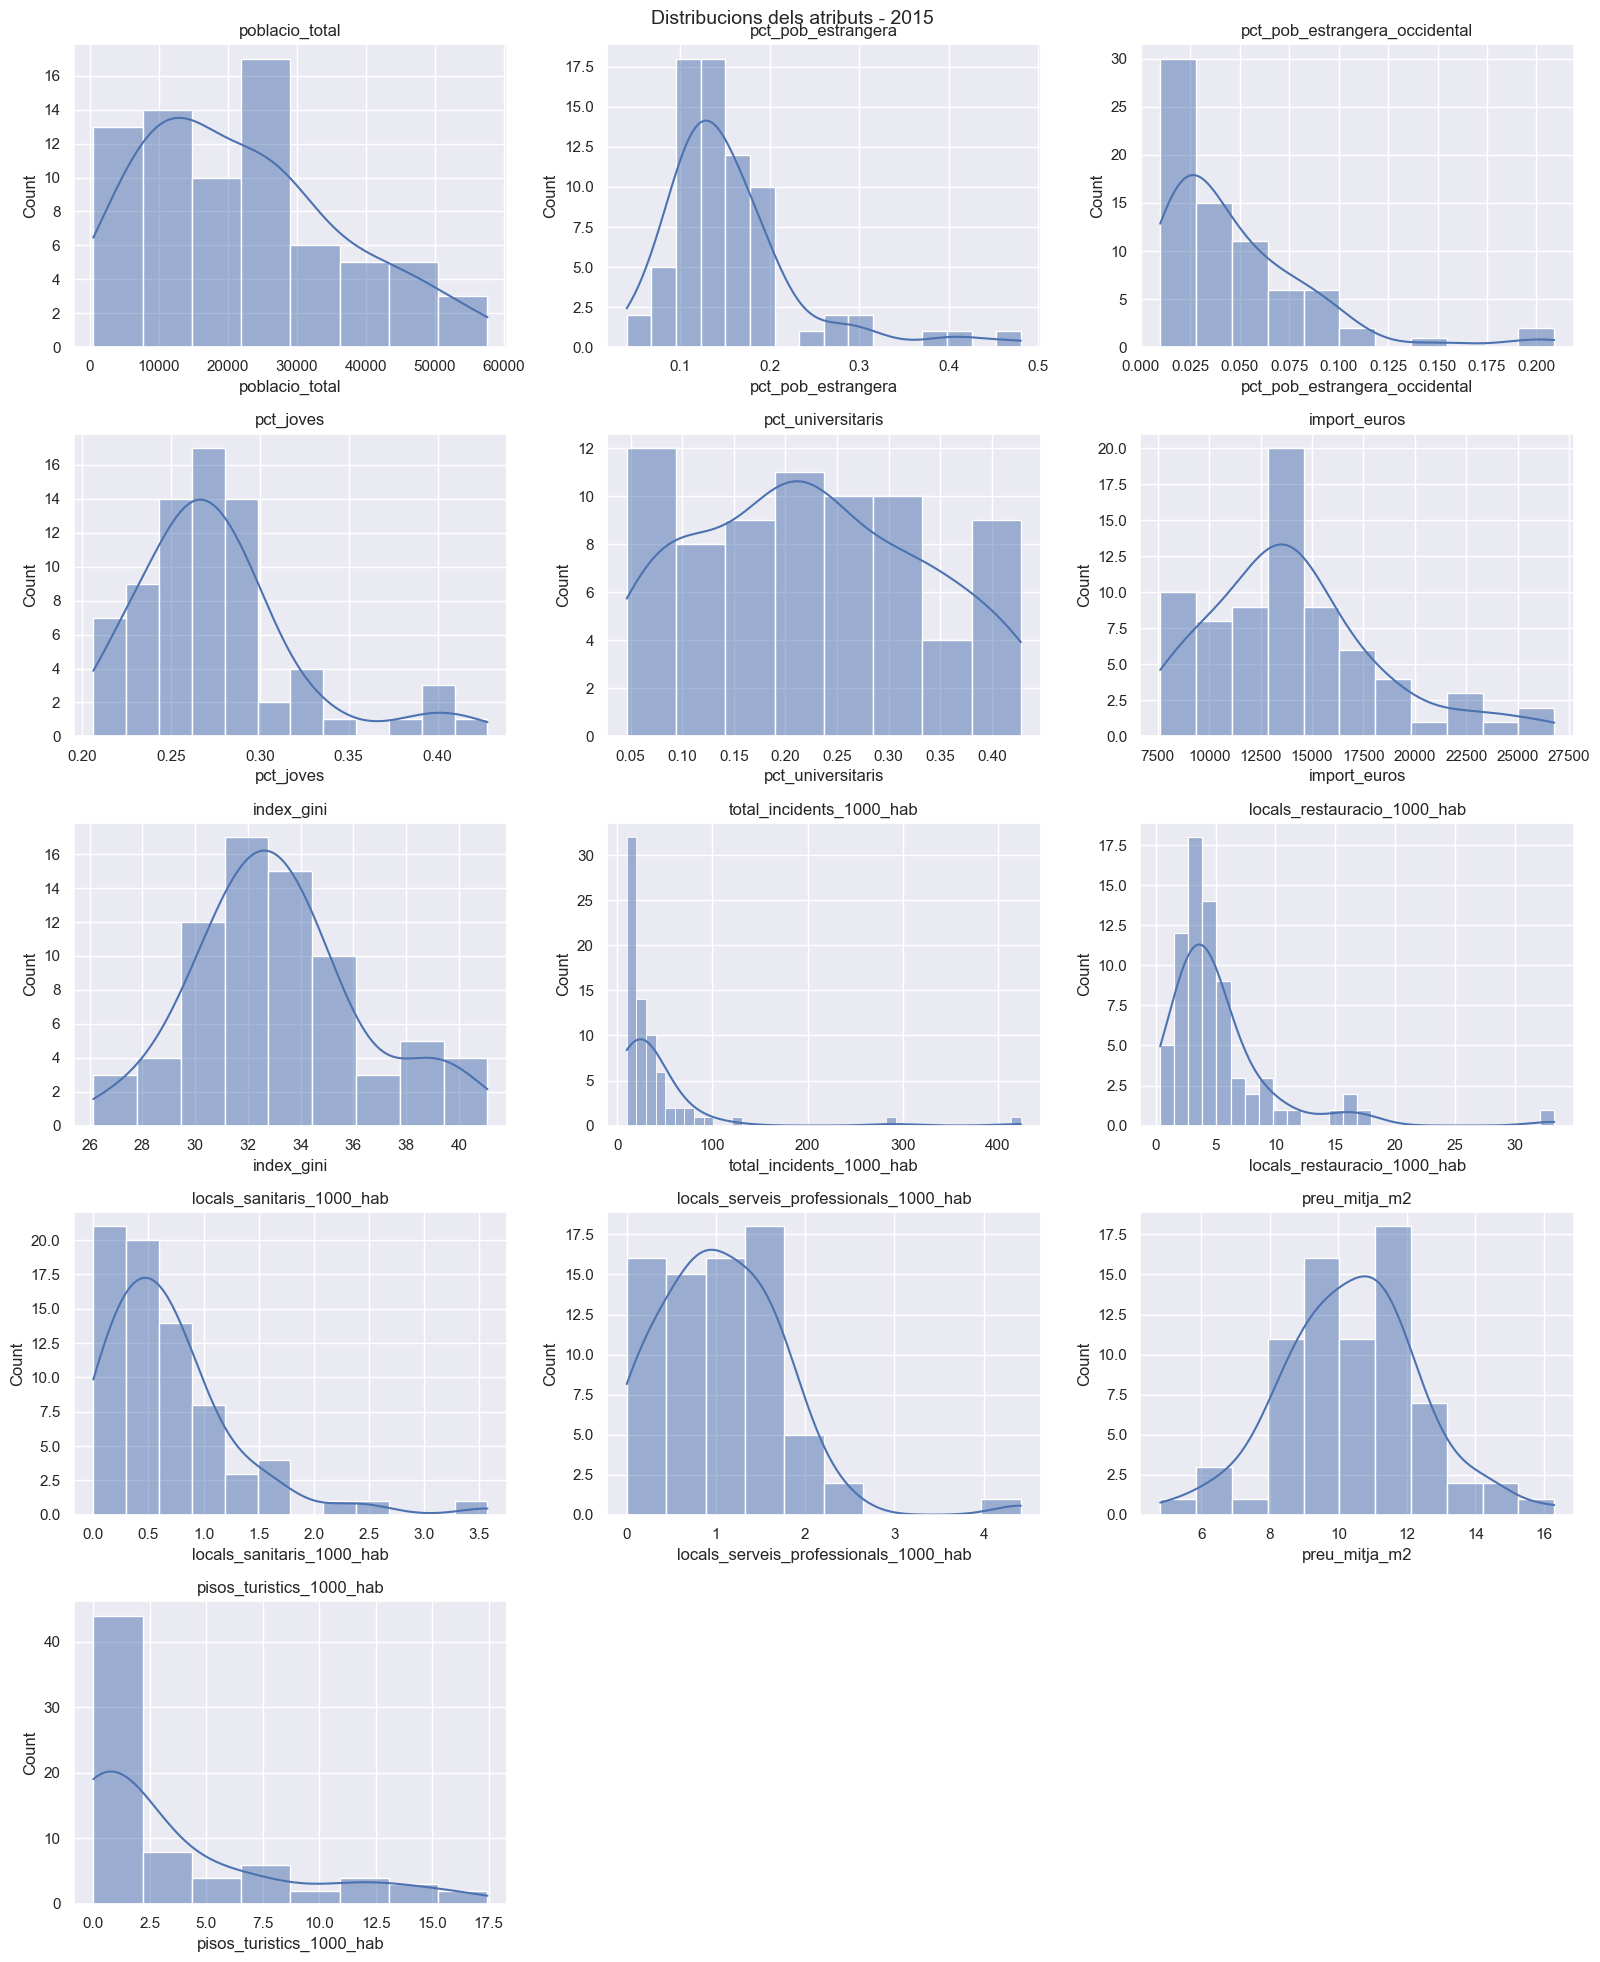

In [15]:
grafics_distribucio(df_2015, 'Distribucions dels atributs - 2015', 'validacio_distribucions_2015.png')

**Observacions:**
- Representació gràfica del que es comentava anteriorment. En general les variables no presenten una distribució normal, més aviat distribucions esbiaixades cap a l'esquerra. Les variables total_incidents_1000_hab i locals_restauracio_1000_hab presenten una assimetria alta, amb possible presència de valors extrems però reals.

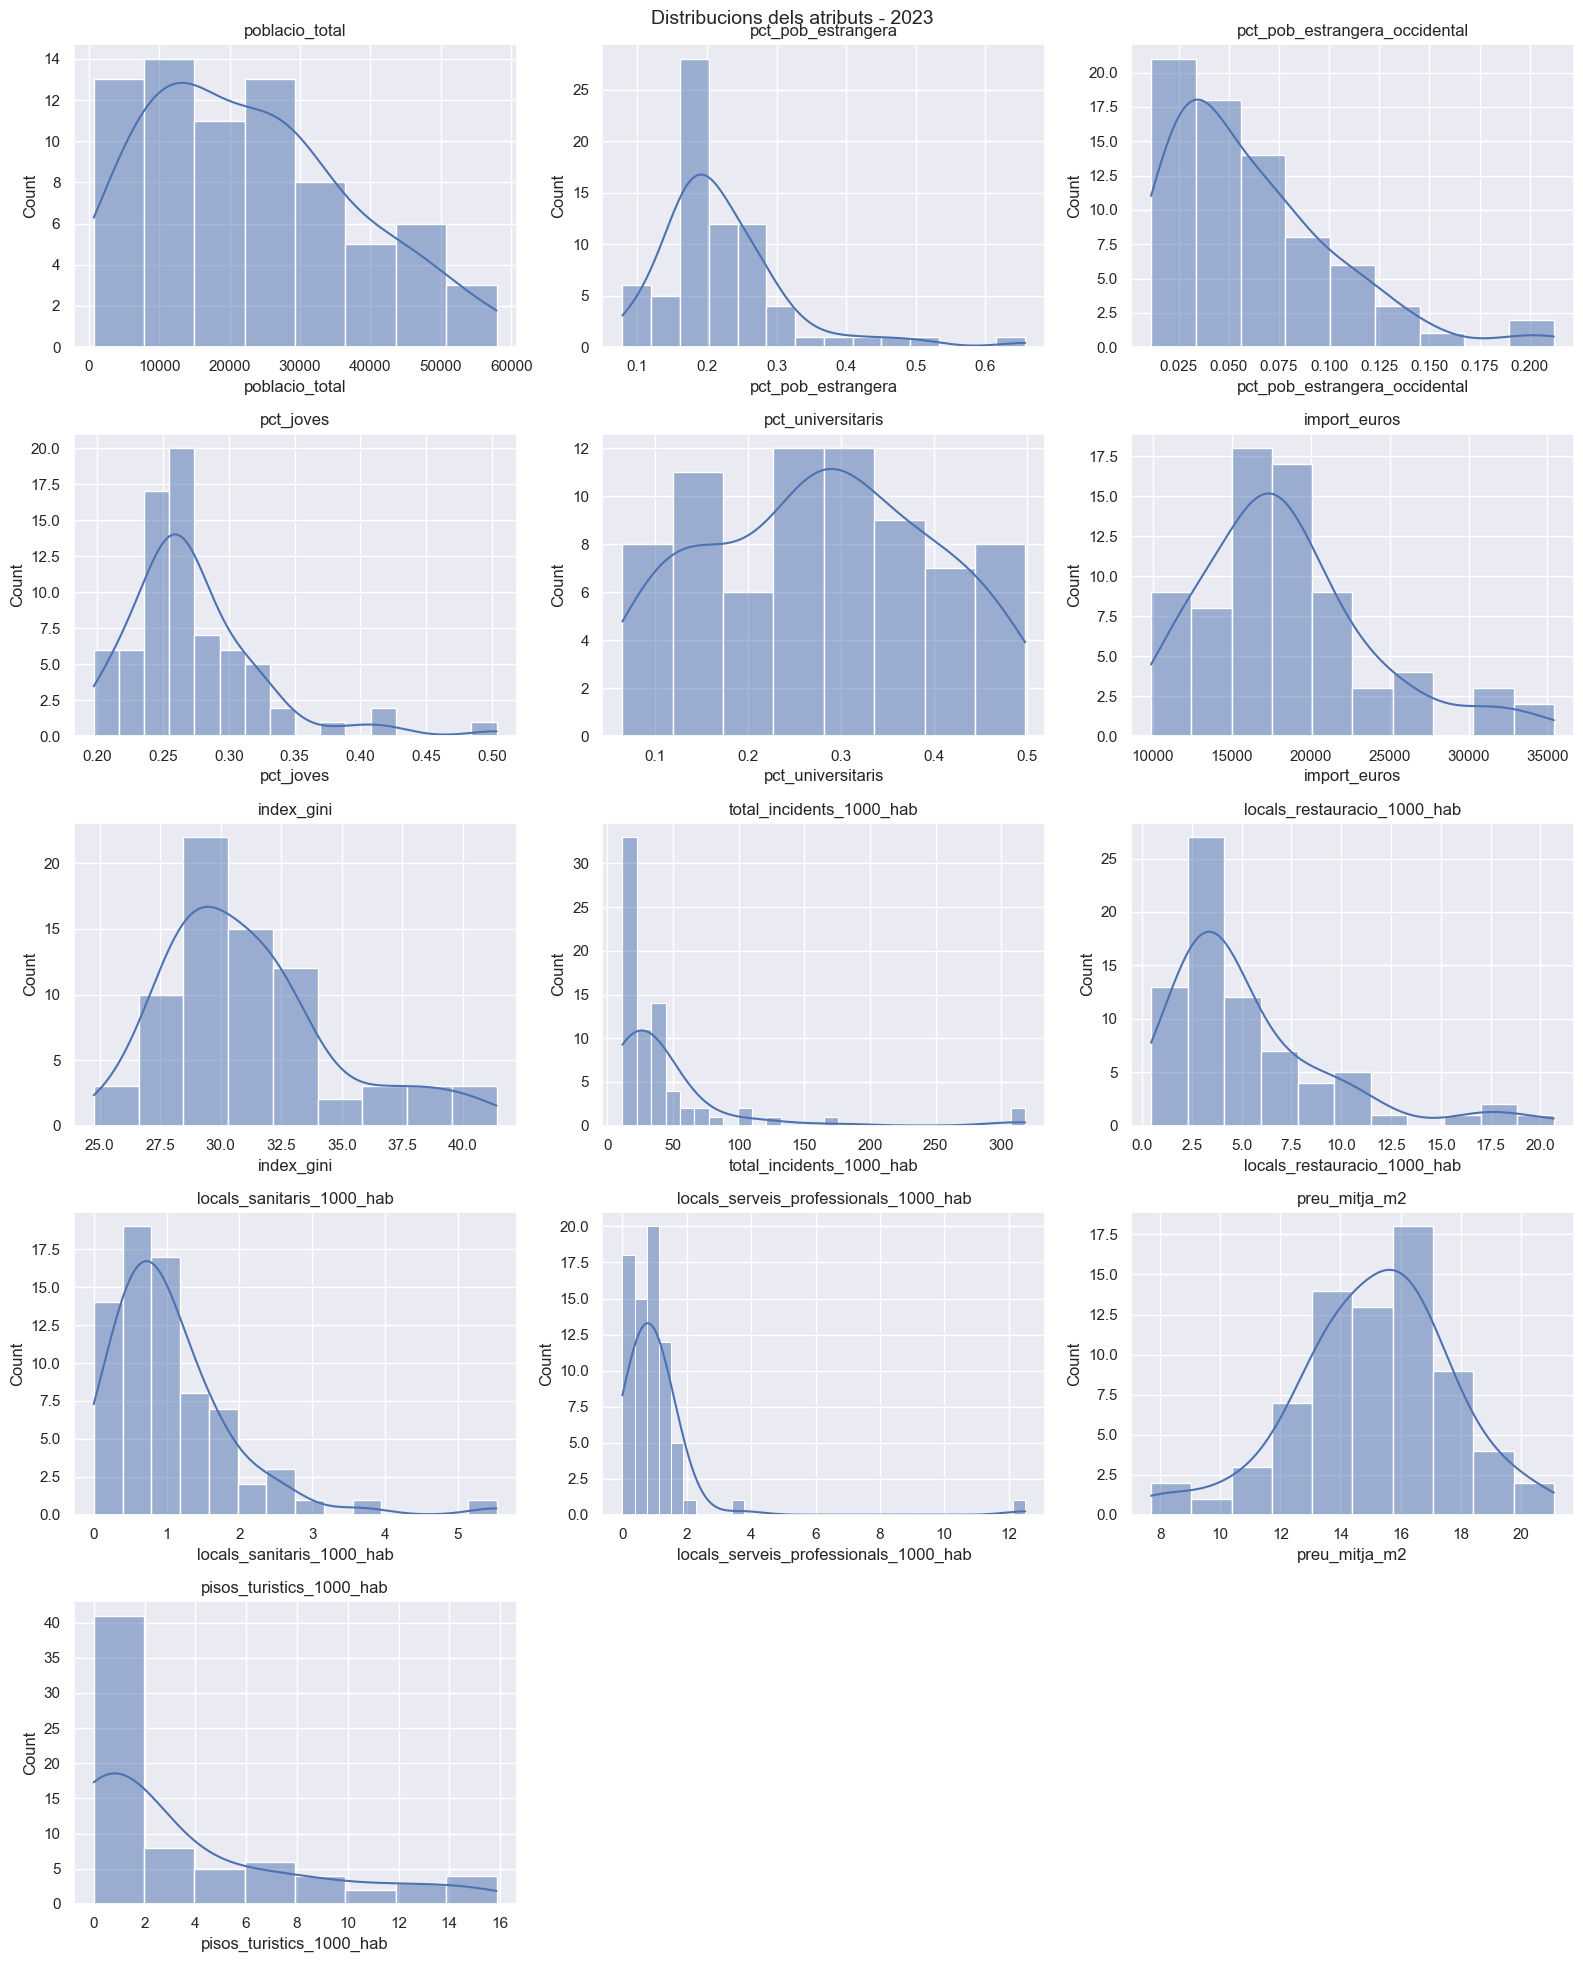

In [16]:
grafics_distribucio(df_2023, 'Distribucions dels atributs - 2023', 'validacio_distribucions_2023.png')

**Observacions:**
- En general s' observen distribucions lleugerament esbiaixades cap a l'esquerra i per tant amb certa asimetria, tal i com hem vist a la taula descriptiva.
- Es pot observar l'assimetria de la variable locals_serveis_professionals_1000_hab, amb una concentracio de les dades al voltant dels valors entre 0 i 2, però amb un valor màzim de 12 locals professionals per cada 1000 habitants.

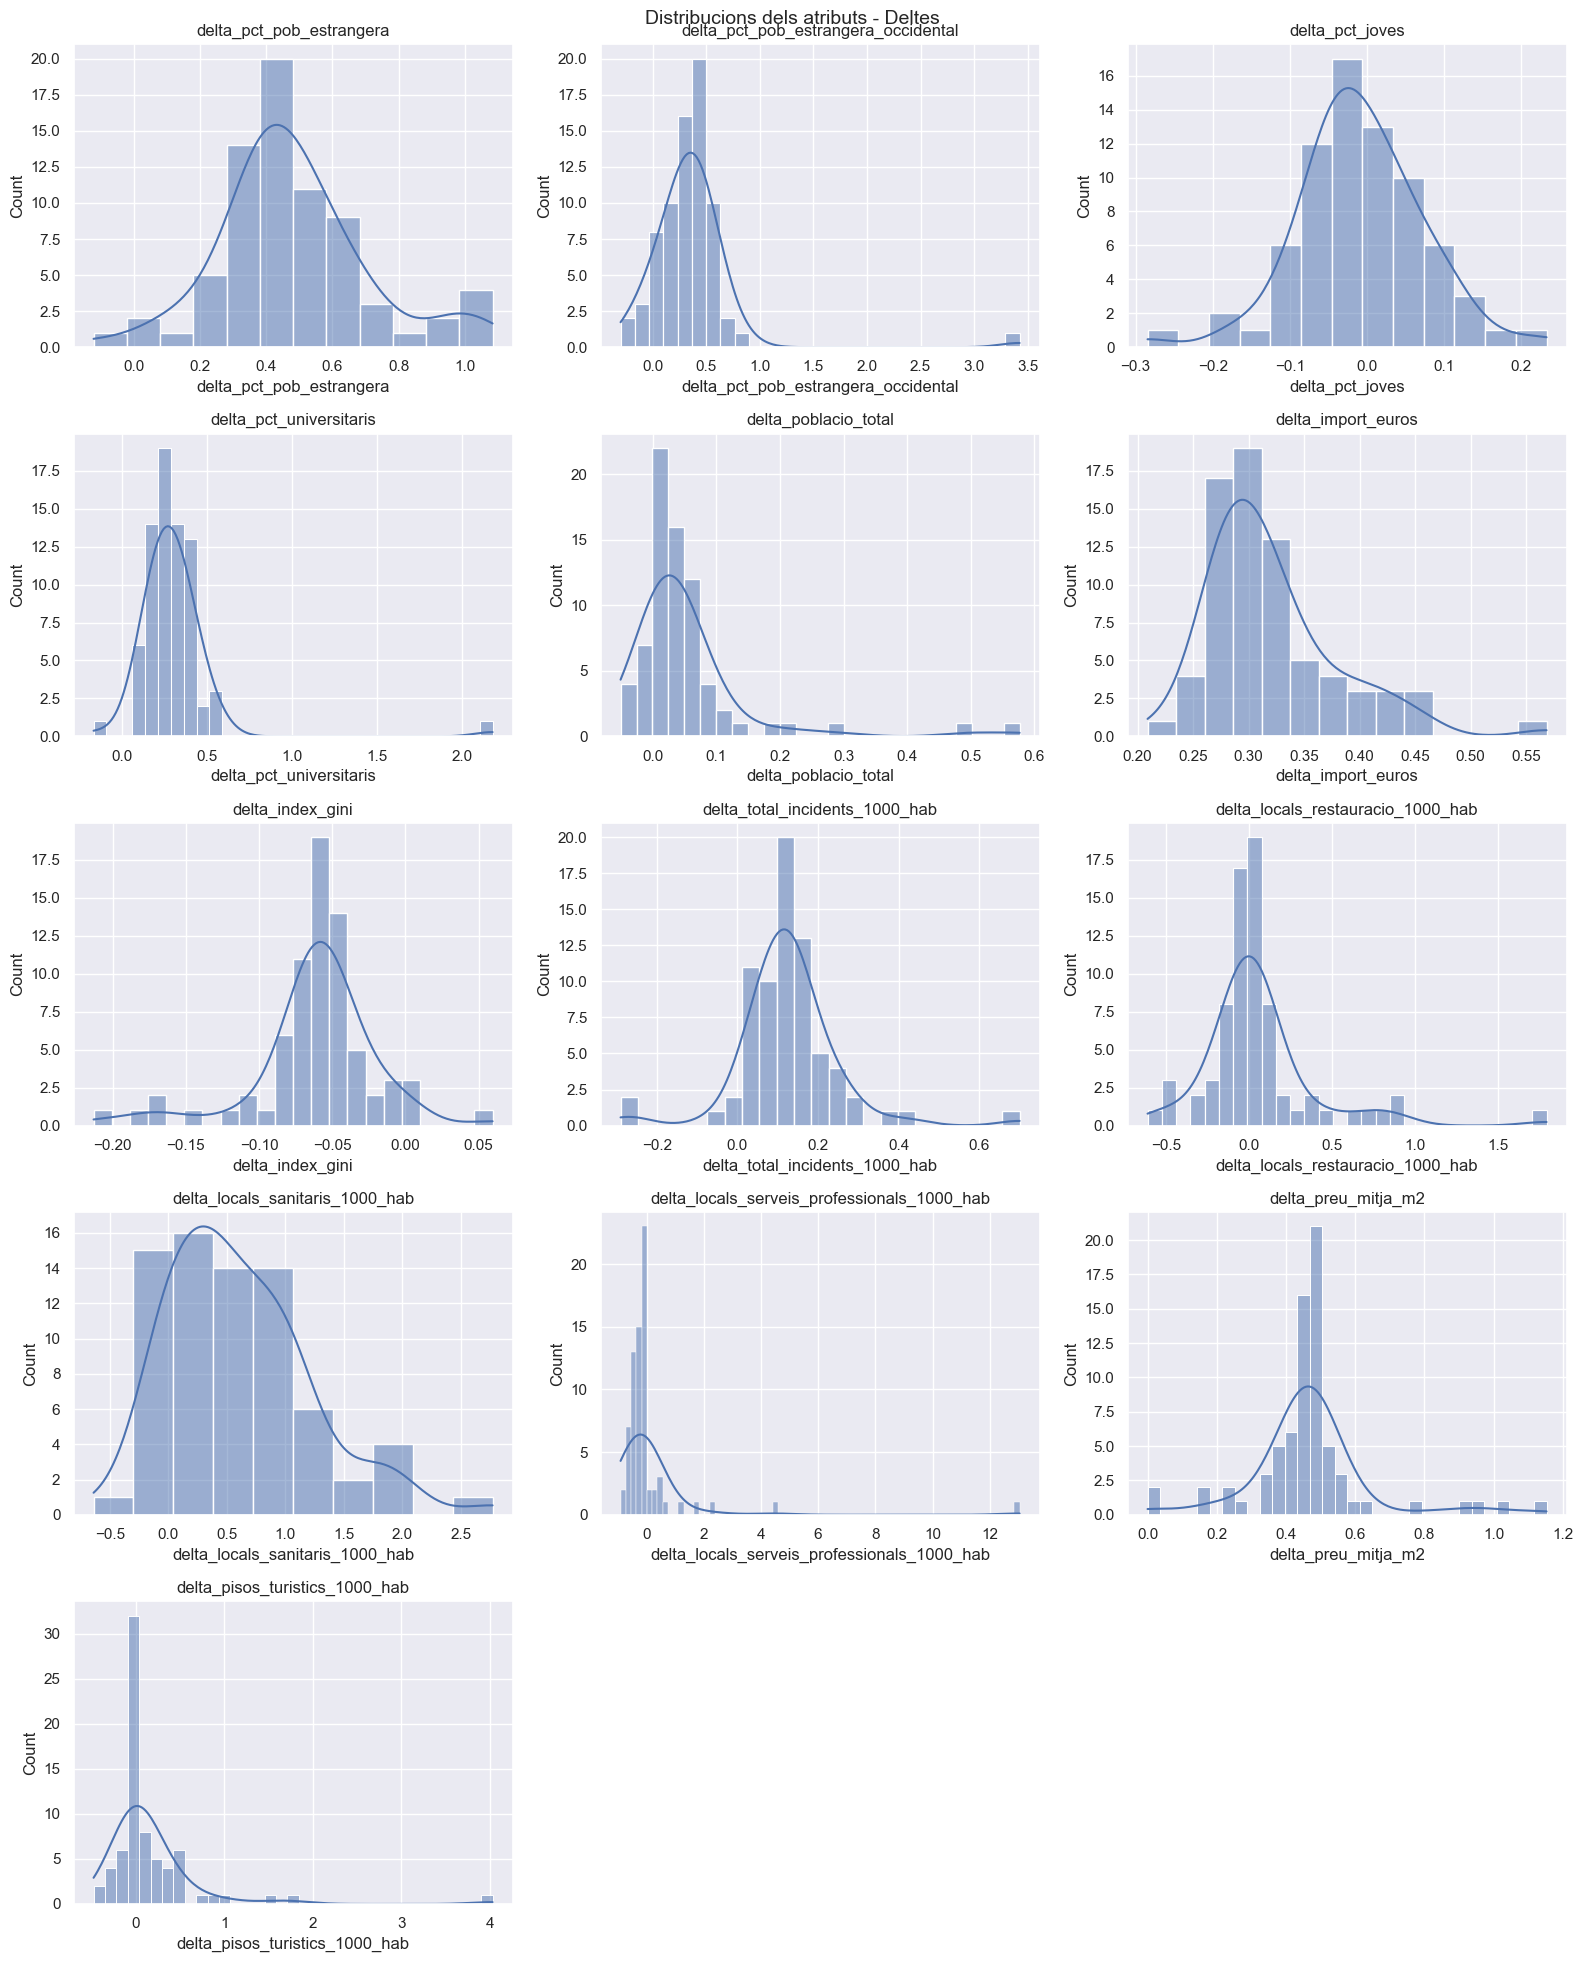

In [17]:
grafics_distribucio(df_deltes, 'Distribucions dels atributs - Deltes', 'validacio_distribucions_deltes.png')

**Observacions:**
- EN general s' observa una tendència de les variables a una distribució normal. No obstant, hi ha variables força skewed com les variables de delta_locals_serveis_professionals_1000_hab amb un valor màxim del 1200% i delta_pisos_turístics_1000_hab.

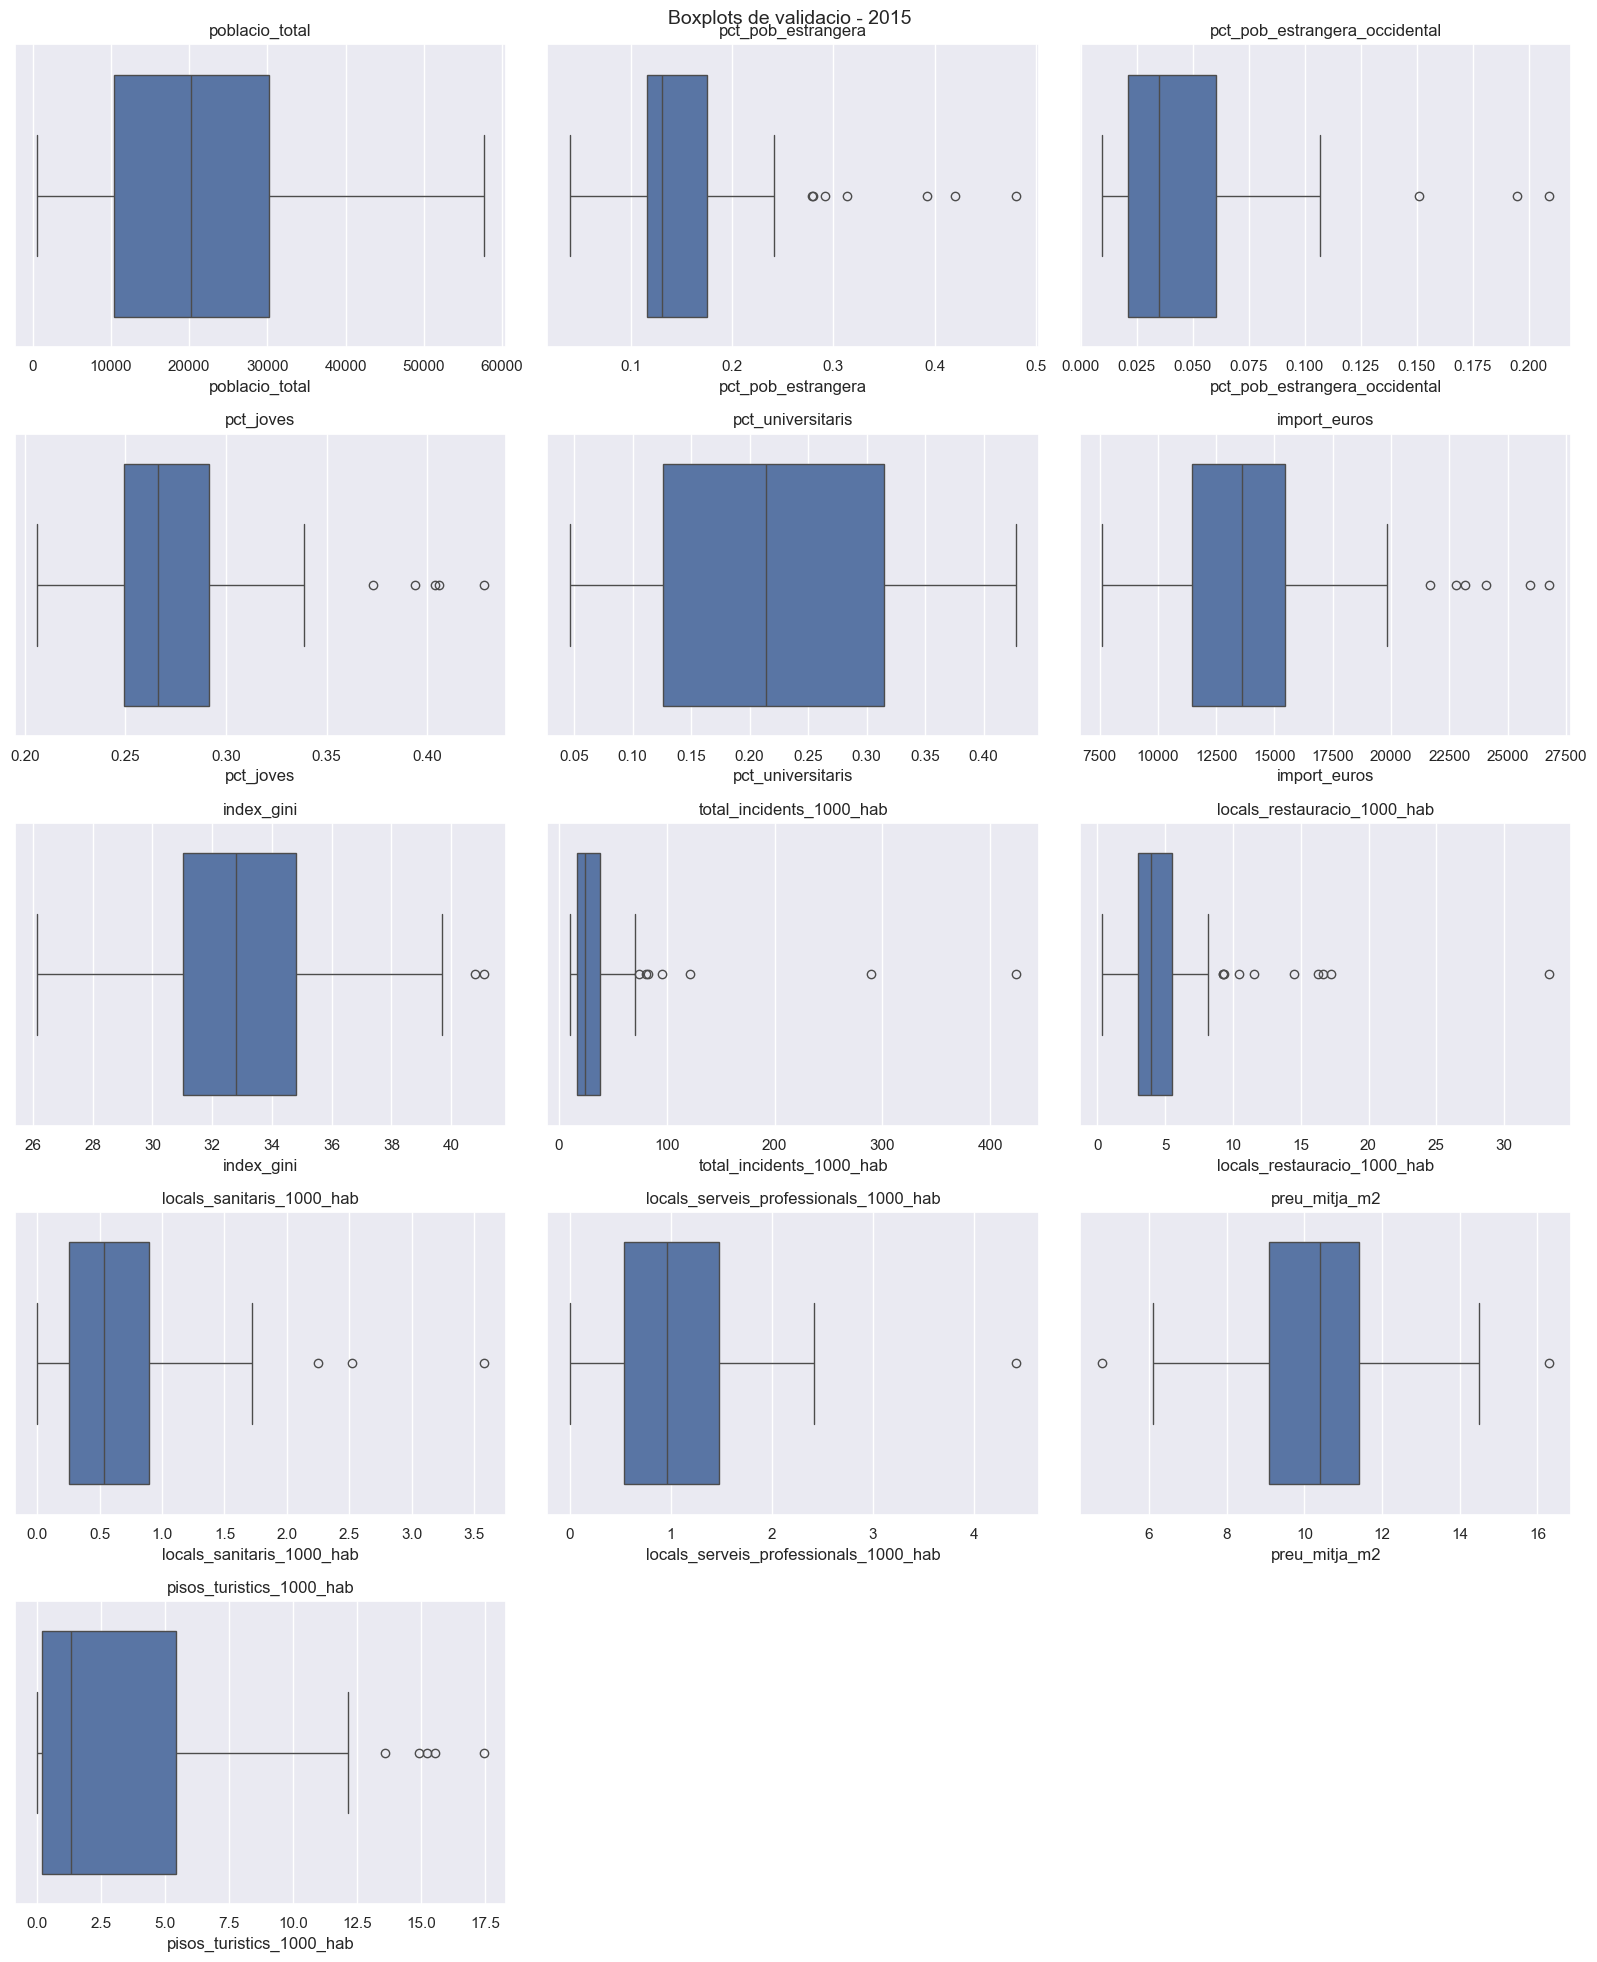

In [18]:
boxplots_validacio(df_2015, 'Boxplots de validacio - 2015', 'validacio_boxplots_2015.png')

**Observacions: **
- Basant-nos en els boxplots, es detecten outliers, sobretot en variables com locals_resturacio_1000_hab, pct_pob_estrangera, etc.

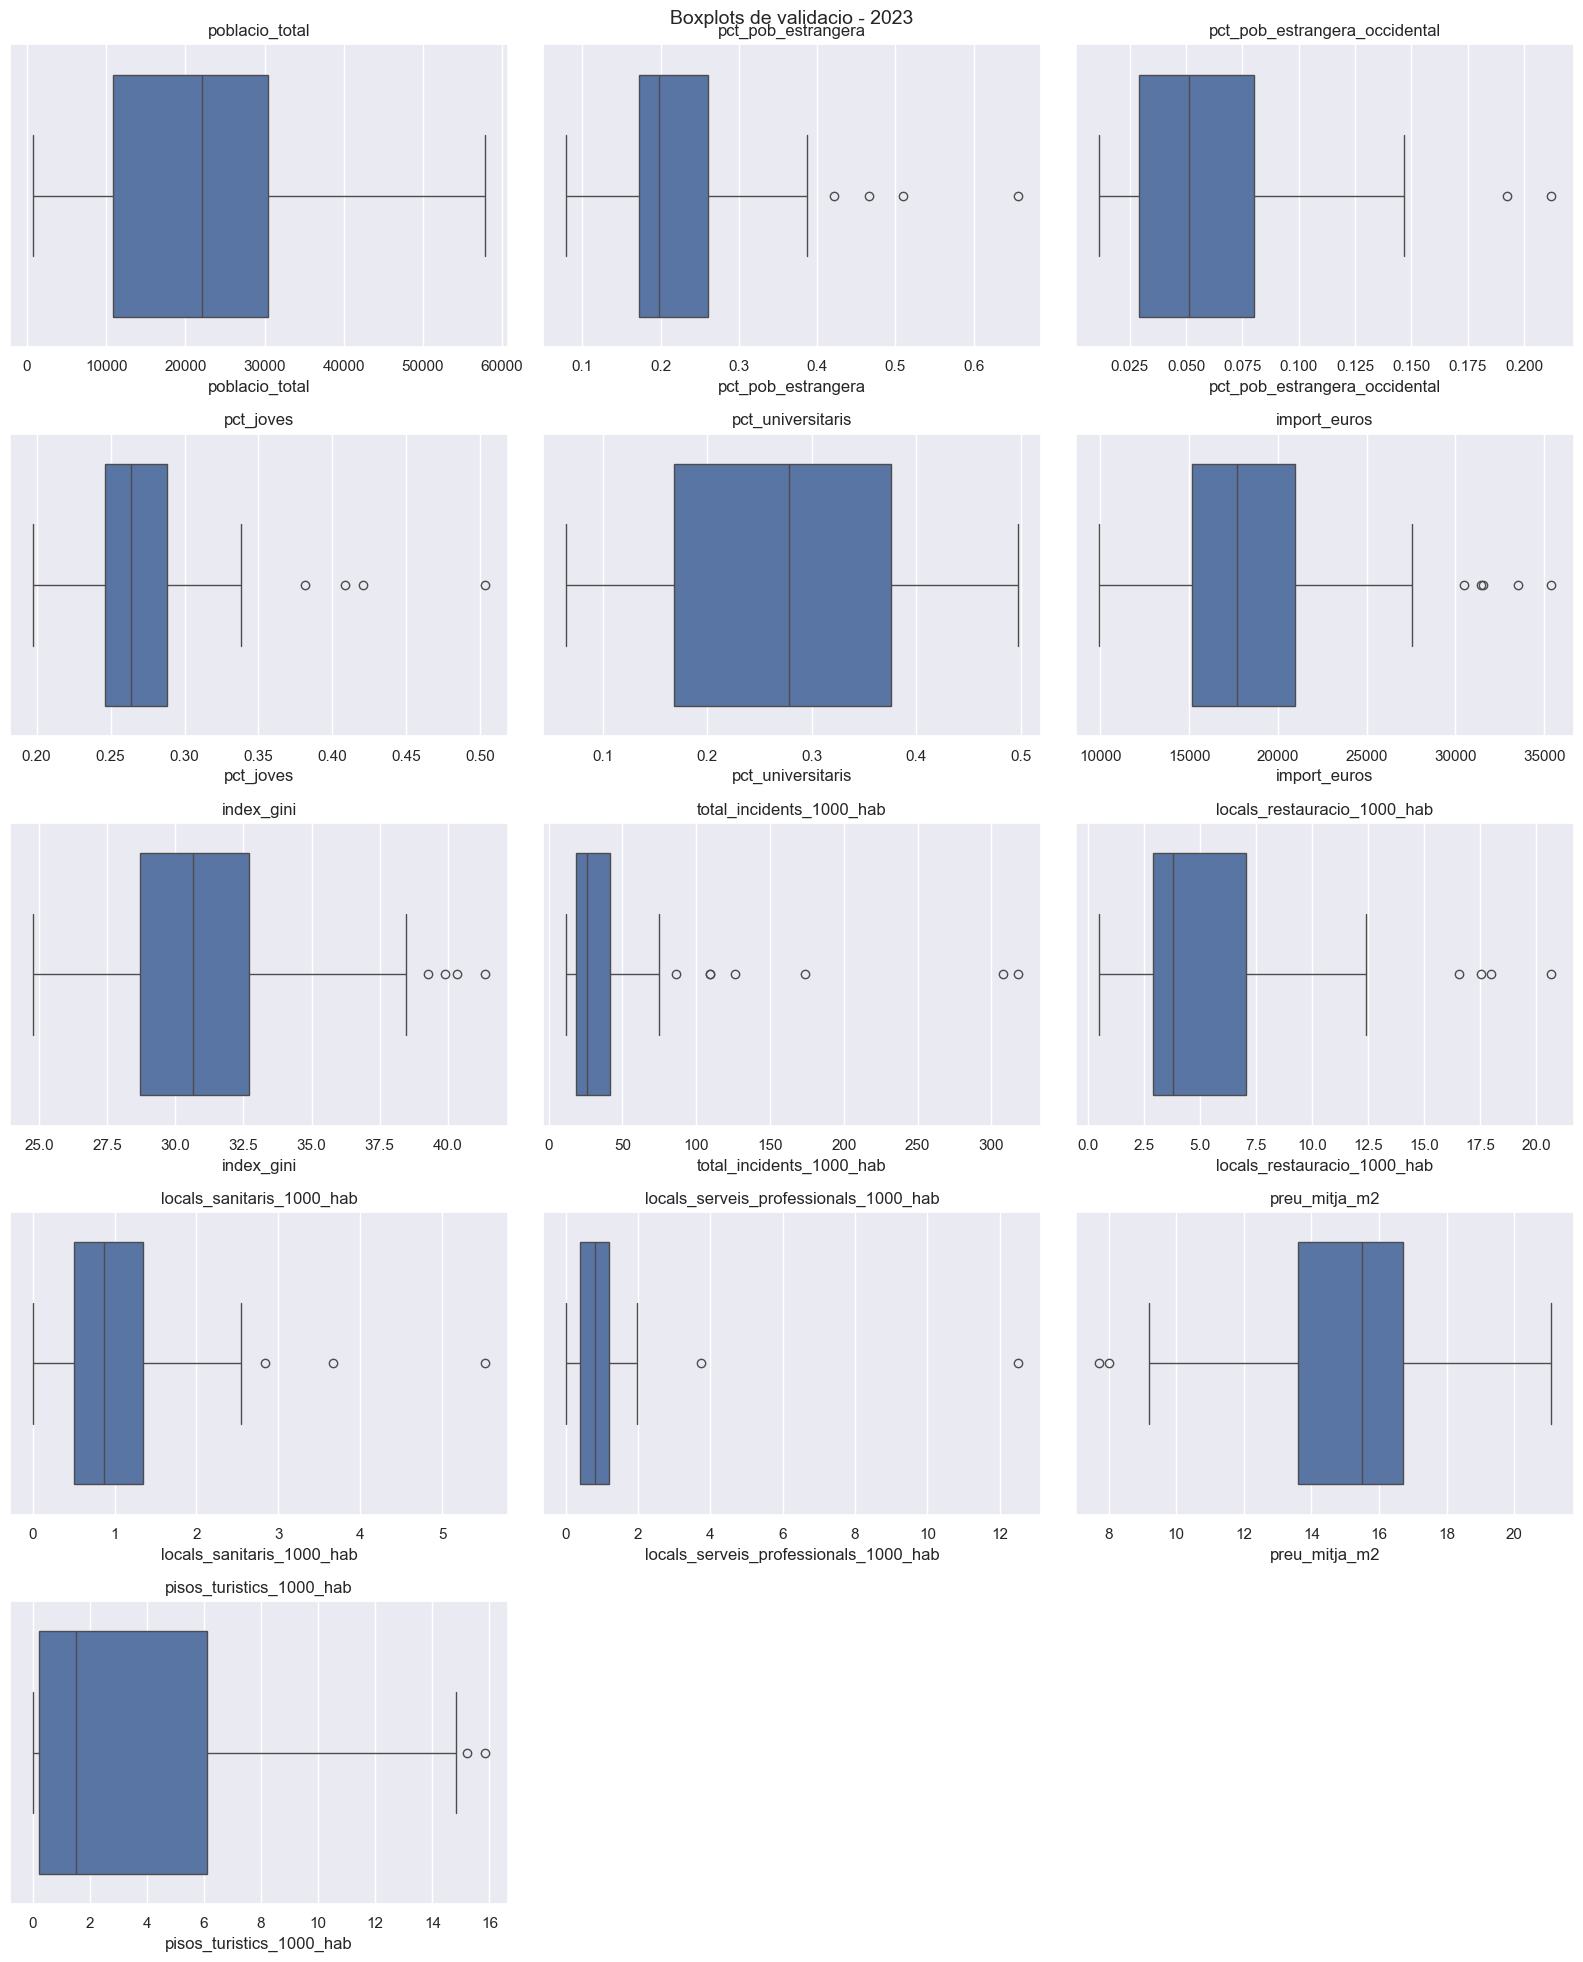

In [19]:
boxplots_validacio(df_2023, 'Boxplots de validacio - 2023', 'validacio_boxplots_2023.png')

**Observacions:**
- S'p observen variables amb outliers com és el cas de locals_serveis_professionals_1000_hab i total_incidents_1000_hab, que com hem vist anteriorment, presenten una distribució força esbiaixada.

In [20]:
df_2023[df_2023["locals_serveis_professionals_1000_hab"] >= 12]

columna (df_2023),codi_barri,poblacio_total,pct_pob_estrangera,pct_pob_estrangera_occidental,pct_joves,pct_universitaris,import_euros,index_gini,total_incidents_1000_hab,locals_restauracio_1000_hab,locals_sanitaris_1000_hab,locals_serveis_professionals_1000_hab,preu_mitja_m2,pisos_turistics_1000_hab
11,12,1678,0.173421,0.051251,0.306317,0.150179,14121.0,31.3,318.235995,6.555423,0.0,12.514899,13.4,1.787843


**Observacions:**
- Sants Montjui presenta un nombre de locals professionals elevat en comparació de 2015. En consequència esbiaixarà tambñe la distribució del seu delta.

In [21]:
df_2023[df_2023["total_incidents_1000_hab"] >= 300]

columna (df_2023),codi_barri,poblacio_total,pct_pob_estrangera,pct_pob_estrangera_occidental,pct_joves,pct_universitaris,import_euros,index_gini,total_incidents_1000_hab,locals_restauracio_1000_hab,locals_sanitaris_1000_hab,locals_serveis_professionals_1000_hab,preu_mitja_m2,pisos_turistics_1000_hab
11,12,1678,0.173421,0.051251,0.306317,0.150179,14121.0,31.3,318.235995,6.555423,0.0,12.514899,13.4,1.787843
41,42,699,0.145923,0.034335,0.290415,0.243205,17668.0,26.6,307.582260,1.430615,0.0,0.000000,15.5,0.000000


**Observacions:**
- El mateix passa amb total_indicents_1000_hab, on els barris d' Horta-Guinardó i Sants Montjuix, presenten valors elevats per a la variable de total incidents.

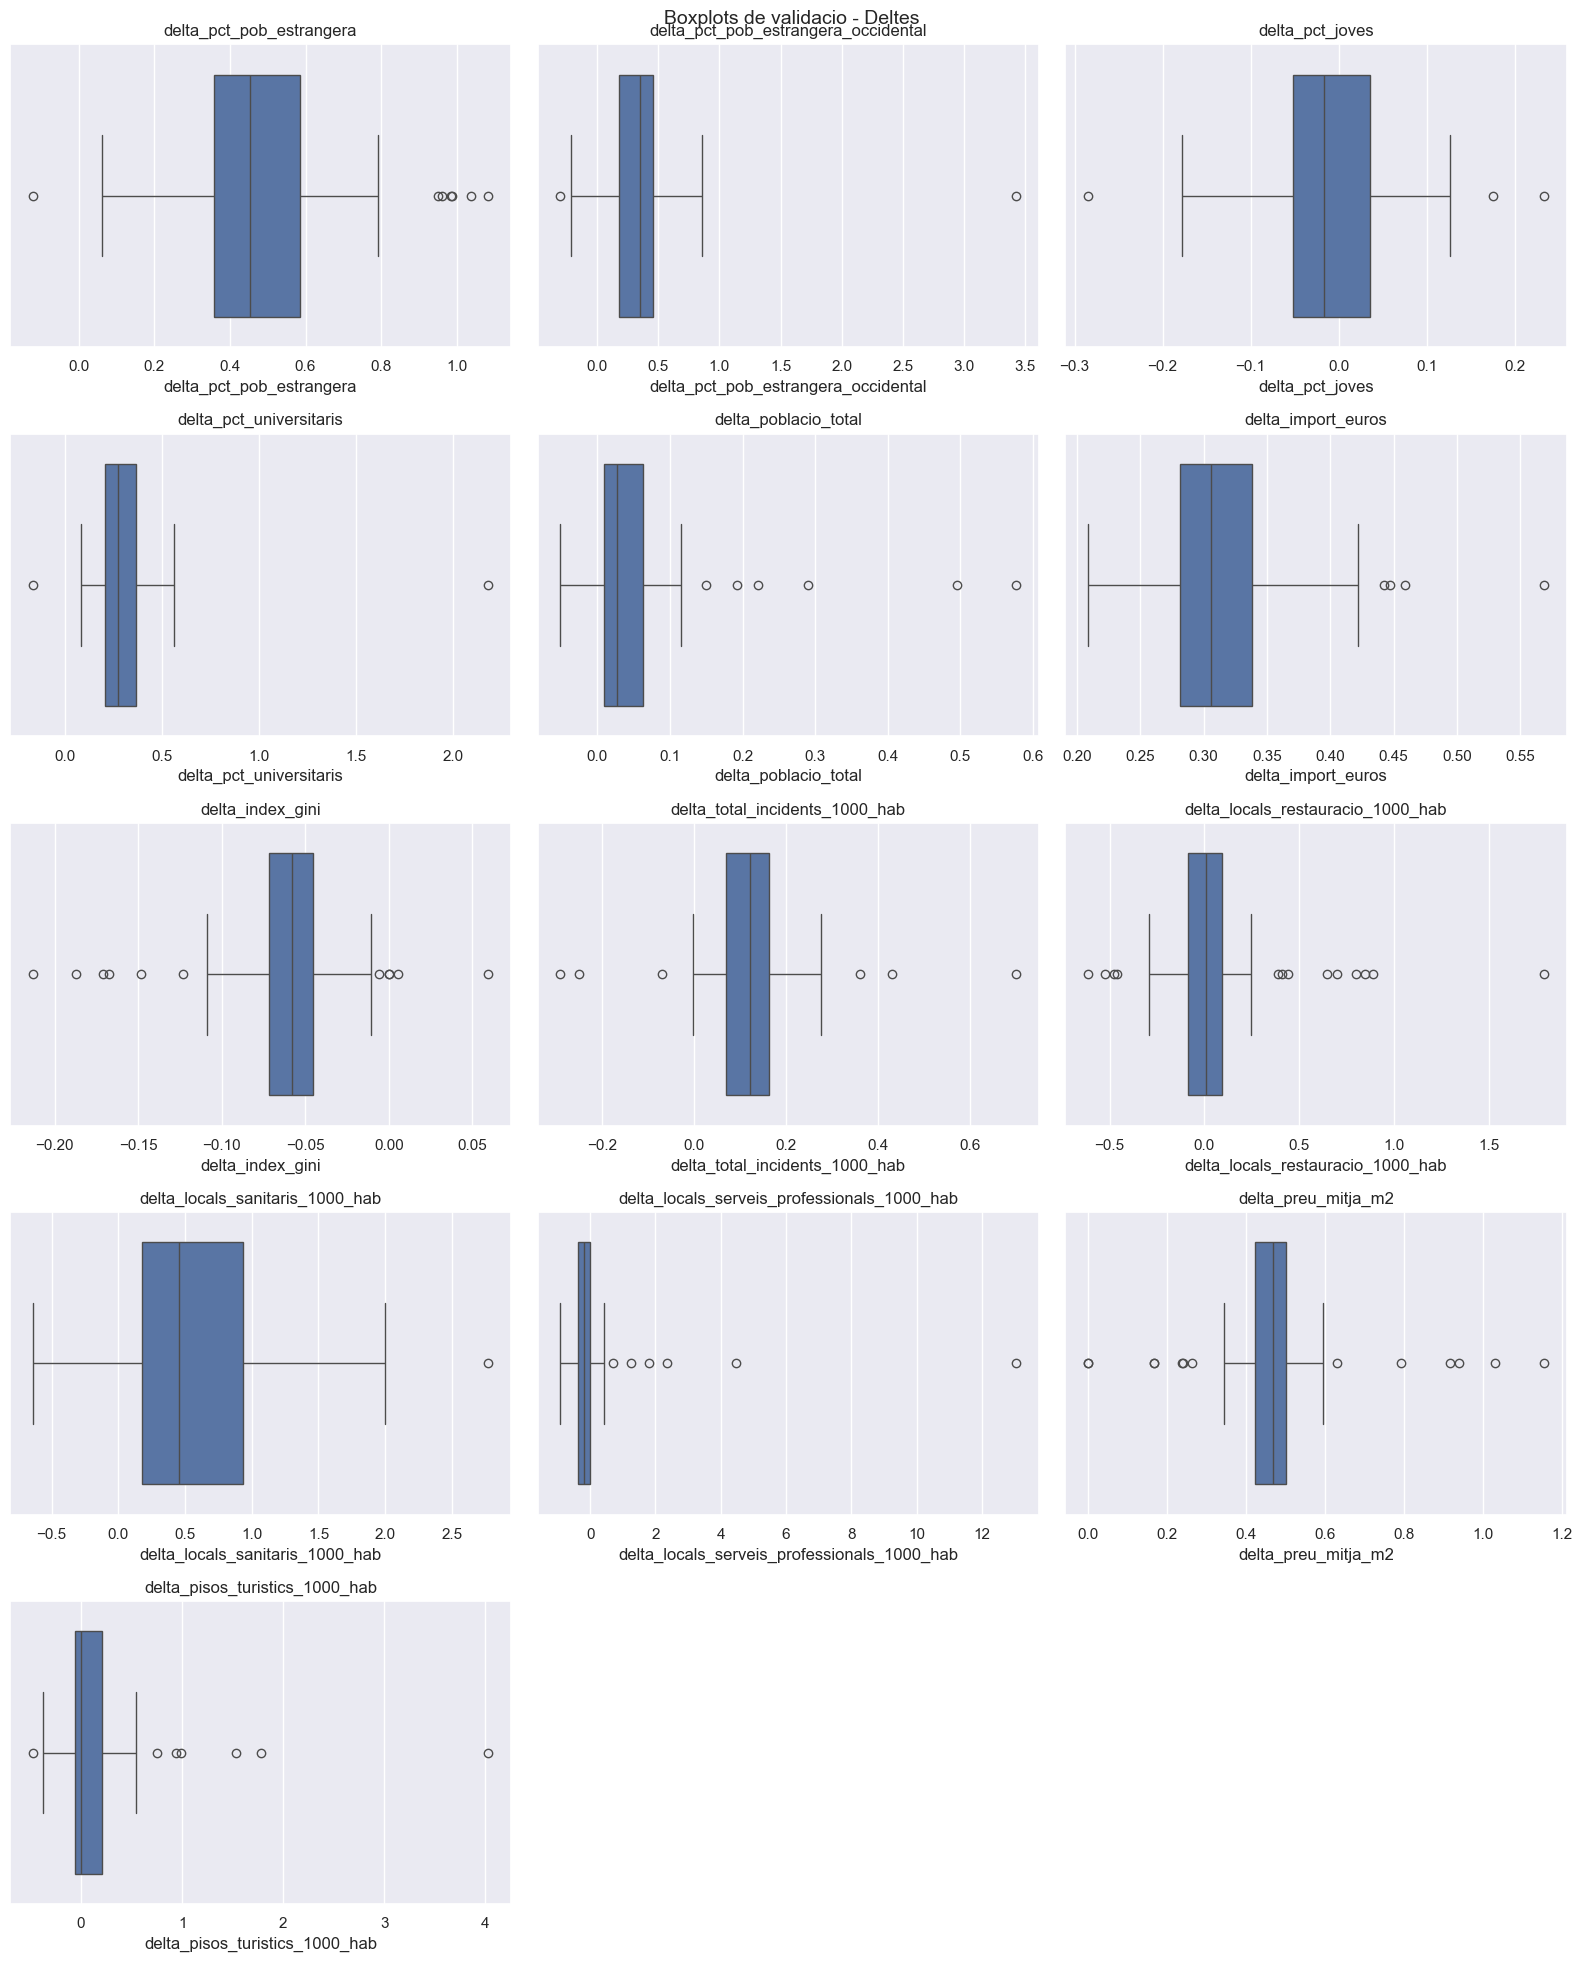

In [22]:
boxplots_validacio(df_deltes, 'Boxplots de validacio - Deltes', 'validacio_boxplots_deltes.png')

**Observacions:**
- Tal i com hem comentat anteriorment, valors alts en les dades de 2023 en comparació a 2015, caussaran *skeweness* a les distribucions dels deltes, com és el cas de delta_locals_serveis_professionals_1000_hab per exemple

Aquests outliers s'han de tractar per tal d' obtenir resultats coherents al clustering. No obstant, donada la limitant del volum de dades, és ideal que no s' eliminin. Això ens deixa en dos possibilitats factibles, o aplicar tècniques com Winsorize, o transformació logarítmica per apropar les dades més elevades amb les més baixes.

Donada la natrualesa de les dades i la seva oficialitat, no es considerarant errònies i per tant es voldrà mantenir tanta informació com sigui possible, sense introduïr arbitrarietat. és doncs per aquest motiu que em decanto per aplicar transformació logarítmica. 

# 4. Validacio temporal i deltes

El dataset de deltes es especialment critic perque pot amplificar problemes derivats de valors molt baixos o iguals a zero a l'any base.

In [23]:
resum_deltes_problematiques = pd.DataFrame({
    'nuls': df_deltes.isna().sum(),
    'infinits': np.isinf(df_deltes.select_dtypes(include=[np.number])).sum().reindex(df_deltes.columns, fill_value=0)
}).query('nuls > 0 or infinits > 0')
resum_deltes_problematiques

,nuls,infinits
columna (df_deltes),,


In [24]:
problemes_deltes.sort_values(['variable', 'codi_barri'])

,dataset,variable,codi_barri,nom_barri,valor


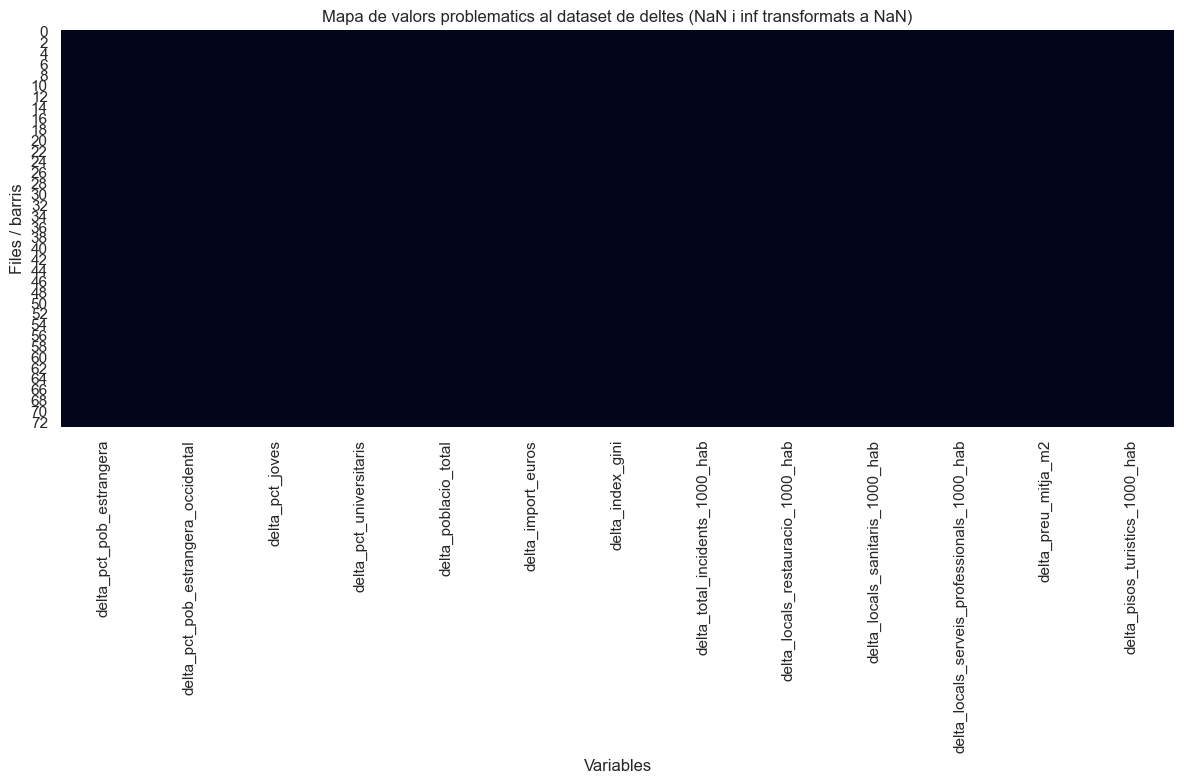

In [25]:
variables_delta = [c for c in df_deltes.columns if c != 'codi_barri']
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df_deltes[variables_delta].replace([np.inf, -np.inf], np.nan).isna(), cbar=False, ax=ax)
ax.set_title('Mapa de valors problematics al dataset de deltes (NaN i inf transformats a NaN)')
ax.set_xlabel('Variables')
ax.set_ylabel('Files / barris')
plt.tight_layout()
plt.show()

**Observacions:**

- no apareixen més valors nuls ni infinits en el conjunt de dades dels deltes


# 5. Validació Correlacions
En aquesta secció explorarem la matriu de correlació per identificar variables amb una forta relació i que només aporten redundància.

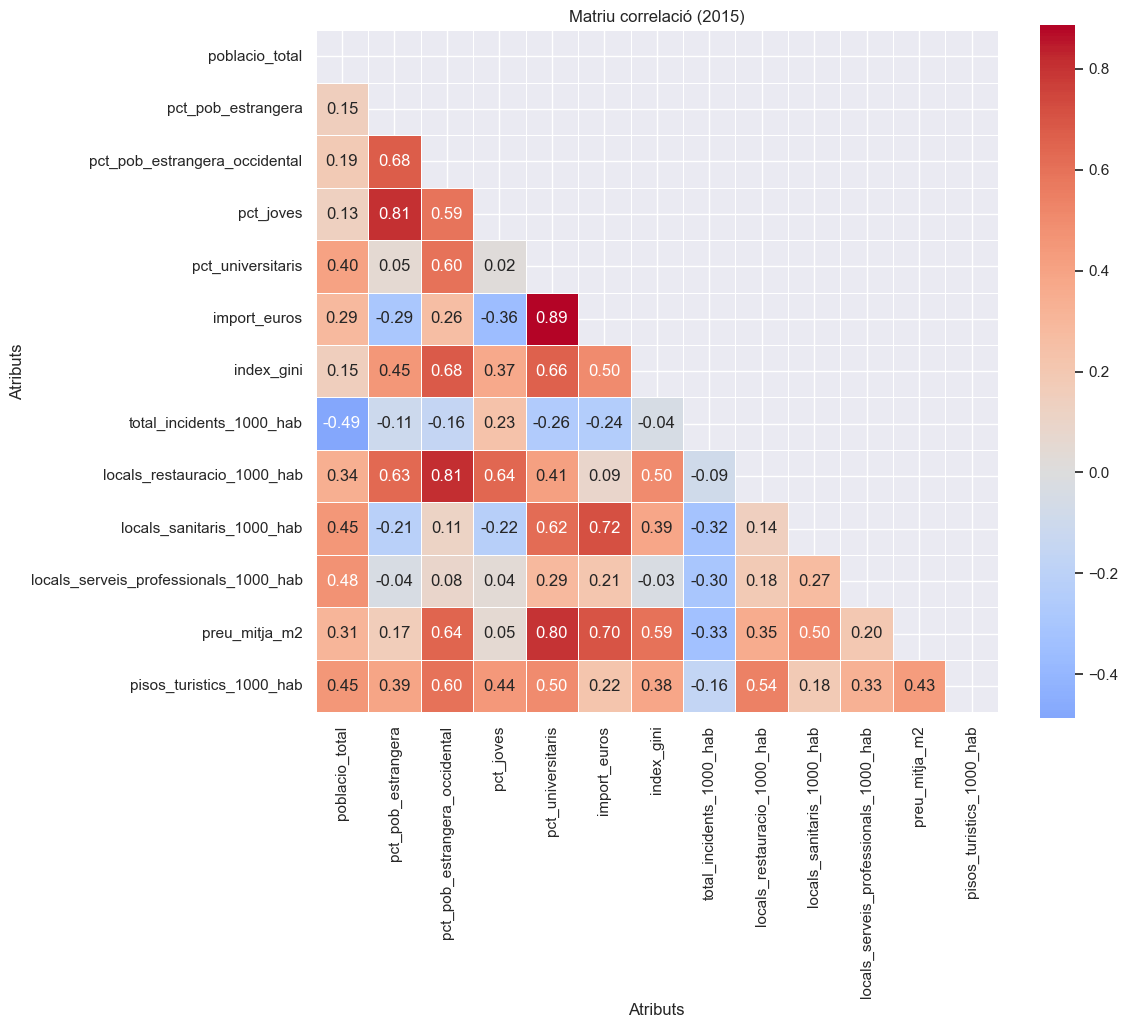

In [26]:
corr_plot(df_2015, "Matriu correlació (2015)", "correlacions_2015.png")

**Observacions:**
- S' observen variables amb una correlació positiva alta. És el cas entre import_euros i pct_universitaris, indicant una concentració de població amb estudis superiors en barris amb major rendes. 
- Existeix una relació positiva també elevada entre pct_joves i pct_pob_estrangera, suggerint que les dinàmiques de migració de població estrangera es concentren en edats de 20 i 40 anys.
- El preu mitja per m2, età també força correlacionat amb el percentatge d'universitaris, indicant preus de lloguer més alt en barris amb major concentració d' estudis universitaris.

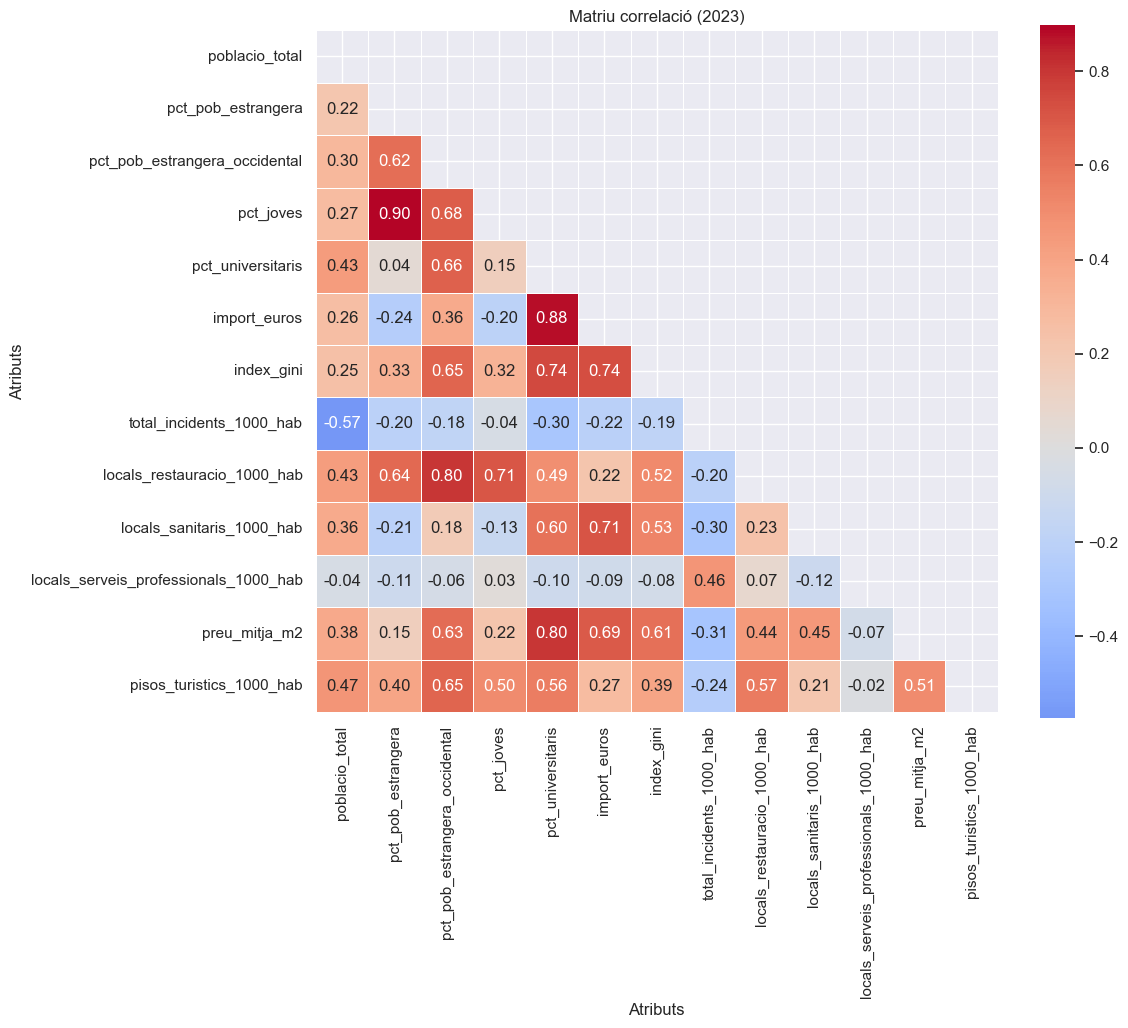

In [27]:
corr_plot(df_2023, "Matriu correlació (2023)", "correlacions_2023.png")

**Observacions**
- Les dades de 2023 pateixen de les mateixes correlacions entre pct_universitaris i import_euros i preu_mitja_m2, indicant barris amb major percentatge d' universitaris estan altament relacionats amb preus més elevats i rendes més altes.
- En aquest cas, destaca una nova correlació forta (0.80) entre locals de restauració (locals_restauracio_1000_hab) i el percentatge destrangers occidentals (pct_pob_estrangera_occidental), suggerint canvis en el teixit comercial per adaptar a les necessitats de la població etrangera occidental (Ameèrica del nord i Europa)

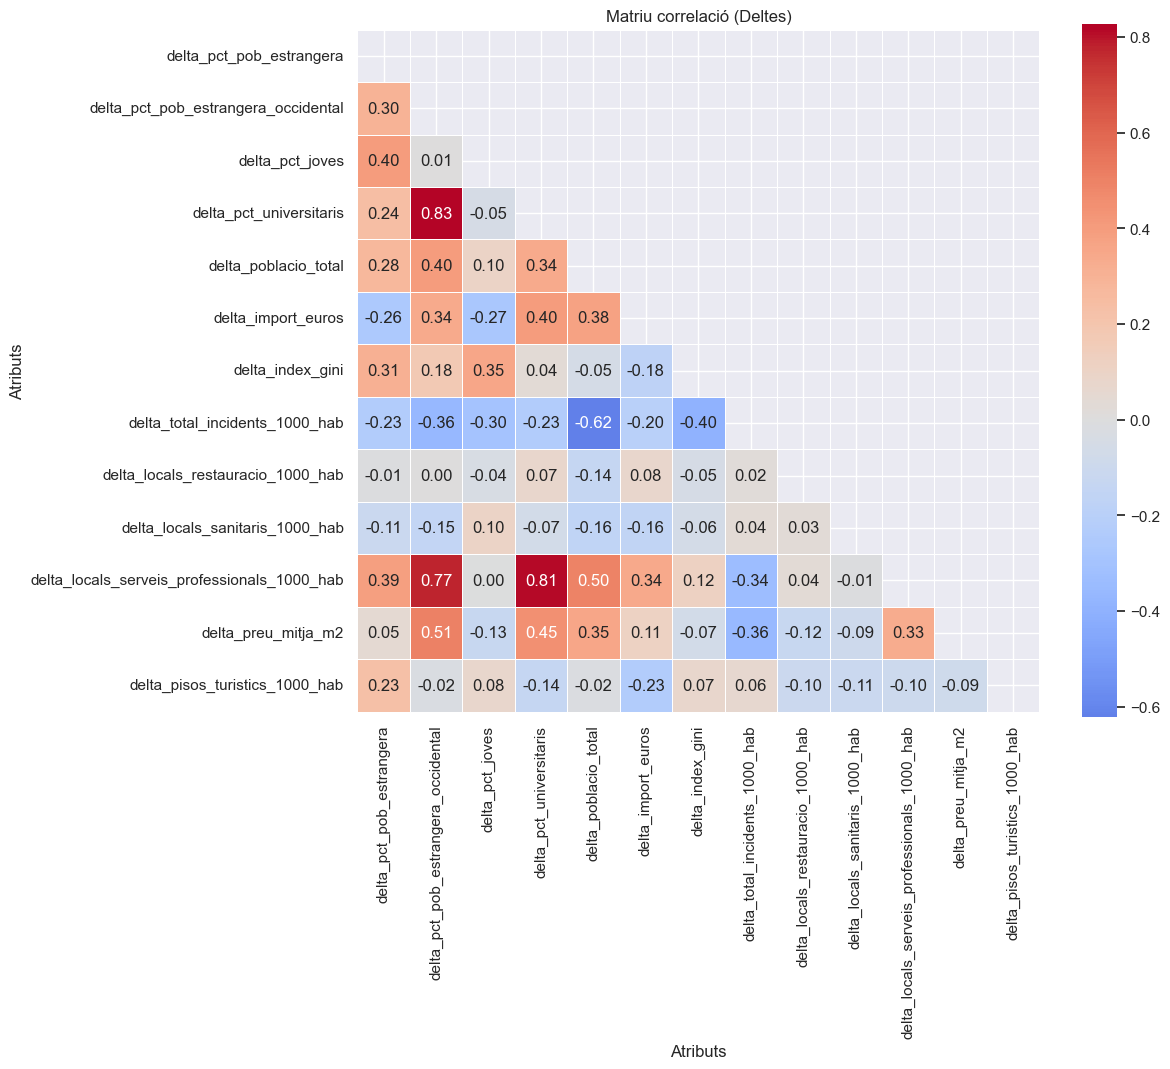

In [28]:
corr_plot(df_deltes, "Matriu correlació (Deltes)", "correlacions_deltes.png")

**Observacions:**
- S'observa una correlació molt elevada (0.87) entre el creixement de la població amb estudis superiors i l' increment de població estrangera occidental, indicant una possible substitució de perfils amb un nivell d'educació més elevat.

# 6. Decisions per al clustering

Aquesta seccio recull decisions metodologiques i punts pendents abans de construir el model de clustering.

In [29]:
decisions = pd.DataFrame([
    {
        'aspecte': 'df_2015 i df_2023',
        'estat': 'valid',
        'comentari': 'No presenten nuls ni duplicats i mantenen una estructura sòlida per barri.'
    },
    {
        'aspecte': 'df_deltes',
        'estat': 'valid',
        'comentari': "Amb una funció més robusta s'han calculat els deltes i ah permès tractar aquells registres amb denominador 0 o nul"
    },
    {
        'aspecte': 'Escala de variables',
        'estat': 'revisat',
        'comentari': "L' estandarització de les dades es durà a terme en el notbook de modelatge"
    },
    {
        'aspecte': 'Outliers',
        'estat': 'revisat',
        'comentari': "La transformació logarítmica (si escau) per a valors absoluts, es valorarà en la part de modelatge. Per altra banda, els outliers presents en el dataset dels deltes s' usarà tècniques com Winsorize"
    },
    {
        'aspecte': 'Correlacions',
        'estat': 'revisat',
        'comentari': 'Utilitzarem PCA per reduir dimensionalitat i gestionar la colinealitat.'
    }

])

decisions

,aspecte,estat,comentari
0,df_2015 i df_2023,valid,No presenten nuls ni duplicats i mantenen una ...
1,df_deltes,valid,Amb una funció més robusta s'han calculat els ...
2,Escala de variables,revisat,L' estandarització de les dades es durà a term...
3,Outliers,revisat,La transformació logarítmica (si escau) per a ...
4,Correlacions,revisat,Utilitzarem PCA per reduir dimensionalitat i g...
